# Art Gallery Problem

In [2]:
import os
import torch
import numpy as np

from skgeom import *
from skgeom.draw import draw

import matplotlib.pyplot as plt
from pathlib import Path

import pandas as pd

from typing   import Tuple


from data_types import VisSample 
from evaluate   import polygon_demo, sample_coverage

In [3]:
# model
# availiable device
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")

Reading Art Gallery instances in the same format as Terrain Guarding instances.

## Dataset description 

convert art  gallery instance files to terrain guarding instance files

In [12]:
dataset_desc = '/home/dseverdi/Radno/MLAG/dataset/AG/agp2009a-simplerand.csv'

               
with open(dataset_desc,'r') as csv_file:
    df = pd.read_csv(csv_file,delimiter=' ')
    
df   

,instance,vertices,strategy,iterations,guards,preProcTime(s),procTime(s),totalTime(s)
0,randsimple-20-17,20,All Vertices,2,3,0.06,0.01,0.07
1,randsimple-20-30,20,All Vertices,3,3,0.06,0.02,0.07
2,randsimple-20-25,20,All Vertices,2,4,0.06,0.02,0.07
3,randsimple-20-24,20,All Vertices,1,3,0.06,0.01,0.06
4,randsimple-20-26,20,All Vertices,1,3,0.05,0.01,0.06
...,...,...,...,...,...,...,...,...
2395,randsimple-2500-17,2500,Single Vertex,57,343,660.83,481.98,1142.81
2396,randsimple-2500-15,2500,Single Vertex,48,346,666.56,482.18,1148.74
2397,randsimple-2500-9,2500,Single Vertex,46,330,662.03,468.19,1130.22
2398,randsimple-2500-5,2500,Single Vertex,66,342,659.44,482.33,1141.76


# RAGNet

In [4]:
from evaluate import polygon_demo
from evaluate import AGNetSearch, Opt

In [6]:
# instance
# data
dataset_dir = '/home/dseverdi/Radno/MLAG/dataset/AG/test'
instances = ['']
instance = os.path.join(dataset_dir,'rand/72/rand-72-6.pol')

## Testbed 1
 * no TGNet pretraining
 * trained
 * no. of epochs: 30

In [10]:
# model
models_dir  = './trained_models/ag_no_pretraining_ne-30_bs-16_hs-256_tfr-0.5_wd-1e-05_lr-0.001_bidirectional_normalized' 
m1  = os.path.join(models_dir,'model_best.pt')

Predicting guards for art gallery.

PtrNet


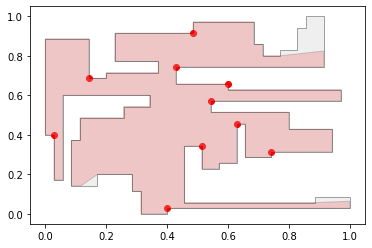

Optimal


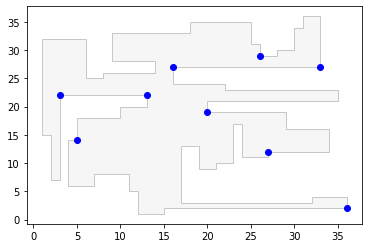

PtrNet coverage:     0.96127208,      ratio=pred/opt: 1.11111111


In [16]:
#opt value
opt = Opt()
# PTrNet search
ns = AGNetSearch(m1)

# prediction
sol_opt    = opt.predict(instance)
sol_ns     = ns.predict(instance,beam_width=4)

print('PtrNet')
ns.show()
print('Optimal')
opt.show()

print(f'PtrNet coverage:     {ns.coverage:2.8f},      ratio=pred/opt: {len(sol_ns)/len(sol_opt):2.8f}')


## Testbed 2
 * TGNet pretrained
 * finetuned
 * no. of epochs: 30
 

In [11]:
# model
models_dir  = './trained_models/ag_ne-30_bs-16_hs-256_tfr-0.5_wd-1e-05_lr-0.001_bidirectional_normalized' 
m2  = os.path.join(models_dir,'model_best.pt')

PtrNet


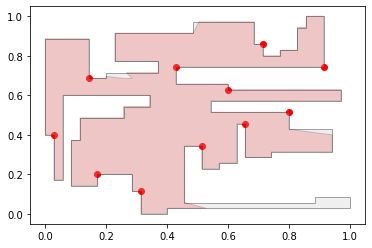

Optimal


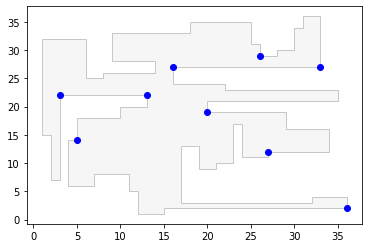

PtrNet coverage:     0.95660830,      ratio=pred/opt: 1.22222222


In [18]:
#opt value
opt = Opt()
# PTrNet search
ns = AGNetSearch(m2)

# prediction
sol_opt    = opt.predict(instance)
sol_ns     = ns.predict(instance,beam_width=4)

print('PtrNet')
ns.show()
print('Optimal')
opt.show()

print(f'PtrNet coverage:     {ns.coverage:2.8f},      ratio=pred/opt: {len(sol_ns)/len(sol_opt):2.8f}')

## Testbed 3

 * TGNet pretrained
 * no fine-tuning
 * no. epochs: 500

In [19]:
# model
models_dir  = './trained_models/tg_ne-500_bs-128_hs-256_tfr-0.5_wd-1e-05_lr-0.001_bidirectional_normalized' 
m3  = os.path.join(models_dir,'model_best.pt')

PtrNet


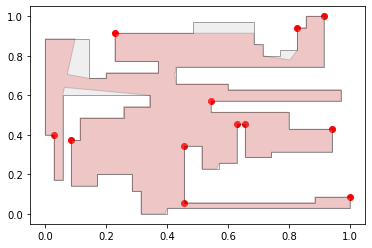

Optimal


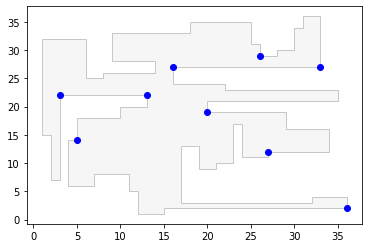

PtrNet coverage:     0.93944577,      ratio=pred/opt: 1.33333333


In [20]:
#opt value
opt = Opt()
# PTrNet search
ns = AGNetSearch(m3)

# prediction
sol_opt    = opt.predict(instance)
sol_ns     = ns.predict(instance,beam_width=4)


print('PtrNet')
ns.show()
print('Optimal')
opt.show()


print(f'PtrNet coverage:     {ns.coverage:2.8f},      ratio=pred/opt: {len(sol_ns)/len(sol_opt):2.8f}')

## Model evaluation per size

In [12]:
# test model per size
def test_model_per_size(
        model_name : str,
        test_dir : str, 
        result_name : str,
        beam_width: int = None, 
        alpha: float = None, 
        vis_compute = polygon_demo) -> pd.DataFrame:
    
    result_dir = 'results'
    # load model
    model = torch.load(model_name)
   
    dfs = []
    sizes = sorted(list(map(int,os.listdir(test_dir))))
    
    for  size in sizes: 
        
        samples = VisSample.read_samples(path=os.path.join(test_dir,f'{size}'))     
        results = sample_coverage(model, samples, beam_width, alpha, vis_compute = polygon_demo)
        
        data = {'size' : [size], 'coverage' : results[0], 'approx' : results[1]}
        dfs.append(pd.DataFrame(data))   
        
    df = pd.concat(dfs).set_index('size').sort_index()
    df.to_json(os.path.join(result_dir,f'{result_name}.json'))

    return df

In [13]:
dataset_dir = '/home/dseverdi/Radno/MLAG/dataset/AG/test'

### VonKoch tests

In [23]:

# test dataset
test_dir = os.path.join(dataset_dir,'vonkoch')

# testing
vonkoch_test_1 = test_model_per_size(m1, test_dir, result_name = 'no_pretrain_vonkoch', beam_width=4, alpha=0.7,vis_compute=polygon_demo)
# min test
vonkoch_test_2 = test_model_per_size(m2, test_dir, result_name = 'pretrain_vonkoch',beam_width=4, alpha=0.7,vis_compute=polygon_demo)

Processing instance vonkoch-500-1 

In [24]:
vonkoch_test_1

,coverage,approx
size,,
500,0.783615,0.0


In [26]:
vonkoch_test_2

,coverage,approx
size,,
500,0.991304,0.0


### `min` tests

In [27]:
test_dir = os.path.join(dataset_dir,'min')
min_test_1 = test_model_per_size(m1, test_dir,result_name = 'no_pretrain_min', beam_width=4, alpha=0.7,vis_compute=polygon_demo)
min_test_2 = test_model_per_size(m2, test_dir, result_name = 'pretrain_min', beam_width=4, alpha=0.7,vis_compute=polygon_demo)

In [30]:
min_test_1

Processing instance min-200-1 

,coverage,approx
size,,
24,0.928571,0.833333
44,0.914634,0.909091
46,0.918604,0.909091
56,0.971698,1.000000
64,0.975409,1.062500
120,0.974357,1.000000
136,0.958645,0.941176
184,0.897783,0.847826
194,0.814128,0.770833


In [31]:
min_test_2

Processing instance min-200-1 

,coverage,approx
size,,
24,0.904761,0.833333
44,1.000000,1.000000
46,1.000000,1.000000
56,1.000000,1.000000
64,1.000000,1.000000
120,0.982905,0.966667
136,0.984961,0.970588
184,0.988949,0.978261
194,0.952880,0.937500


### `rand` test

In [34]:
test_dir = os.path.join(dataset_dir,'rand')
rand_test_1 = test_model_per_size(m1, test_dir,result_name = 'no_pretrain_rand', beam_width=4, alpha=0.7,vis_compute=polygon_demo)
rand_test_2 = test_model_per_size(m2, test_dir, result_name = 'pretrain_rand', beam_width=4, alpha=0.7,vis_compute=polygon_demo)

Processing instance rand-1000-9  

In [35]:
rand_test_1

,coverage,approx
size,,
8,0.958333,1.000000
10,0.875000,1.000000
12,0.735821,1.500000
16,0.987599,0.833333
18,0.900001,1.500000
...,...,...
600,0.360273,0.331272
700,0.311412,0.286038
800,0.267189,0.250645


In [36]:
rand_test_2

,coverage,approx
size,,
8,1.000000,1.000000
10,1.000000,1.000000
12,0.992857,1.500000
16,0.986260,1.000000
18,1.000000,1.000000
...,...,...
600,0.369446,0.270202
700,0.325549,0.228718
800,0.291960,0.204284


### `random` test

In [16]:
test_dir = os.path.join(dataset_dir,'random')
random_test_1 = test_model_per_size(m1, test_dir,result_name = 'no_pretrain_random', beam_width=4, alpha=0.7,vis_compute=polygon_demo)
random_test_2 = test_model_per_size(m2, test_dir, result_name = 'pretrain_random', beam_width=4, alpha=0.7,vis_compute=polygon_demo)

Processing instance random-1500-19 Problem on random-1500-19
CUDA out of memory. Tried to allocate 20.00 MiB (GPU 0; 7.79 GiB total capacity; 5.53 GiB already allocated; 47.38 MiB free; 6.27 GiB reserved in total by PyTorch)
Processing instance random-1750-13 Problem on random-1750-13
CUDA out of memory. Tried to allocate 20.00 MiB (GPU 0; 7.79 GiB total capacity; 5.36 GiB already allocated; 57.38 MiB free; 6.26 GiB reserved in total by PyTorch)
Processing instance random-1750-25 Problem on random-1750-25
CUDA out of memory. Tried to allocate 20.00 MiB (GPU 0; 7.79 GiB total capacity; 5.38 GiB already allocated; 56.69 MiB free; 6.28 GiB reserved in total by PyTorch)
Processing instance random-1750-28 Problem on random-1750-28
CUDA out of memory. Tried to allocate 20.00 MiB (GPU 0; 7.79 GiB total capacity; 5.38 GiB already allocated; 59.06 MiB free; 6.28 GiB reserved in total by PyTorch)
Processing instance random-2000-8 Problem on random-2000-8
CUDA out of memory. Tried to allocate 20.

In [17]:
random_test_1

,coverage,approx
size,,
20,0.940972,0.750000
40,0.919454,0.935374
60,0.885119,0.842424
100,0.928255,0.996644
200,0.865601,0.952663
300,0.676461,0.662071
400,0.535812,0.493635
500,0.439369,0.402278
600,0.355311,0.333462


In [18]:
random_test_2

,coverage,approx
size,,
20,0.940972,0.750000
40,0.941428,1.003401
60,0.931202,0.939394
100,0.868054,0.866412
200,0.834219,0.760633
300,0.652904,0.513623
400,0.541114,0.394243
500,0.430840,0.316057
600,0.357545,0.256026


### `randsimple` test

In [15]:
test_dir = os.path.join(dataset_dir,'random')
randsimple_test_1 = test_model_per_size(m1, test_dir,result_name = 'no_pretrain_randsimple', beam_width=4, alpha=0.7,vis_compute=polygon_demo)
randsimple_test_2 = test_model_per_size(m2, test_dir, result_name = 'pretrain_randsimple', beam_width=4, alpha=0.7,vis_compute=polygon_demo)

Processing instance random-1500-19 Problem on random-1500-19
CUDA out of memory. Tried to allocate 20.00 MiB (GPU 0; 7.79 GiB total capacity; 5.23 GiB already allocated; 46.31 MiB free; 5.94 GiB reserved in total by PyTorch)
Processing instance random-1750-13 Problem on random-1750-13
CUDA out of memory. Tried to allocate 20.00 MiB (GPU 0; 7.79 GiB total capacity; 5.13 GiB already allocated; 49.88 MiB free; 5.98 GiB reserved in total by PyTorch)
Processing instance random-1750-25 Problem on random-1750-25
CUDA out of memory. Tried to allocate 20.00 MiB (GPU 0; 7.79 GiB total capacity; 5.16 GiB already allocated; 51.19 MiB free; 6.03 GiB reserved in total by PyTorch)
Processing instance random-1750-28 Problem on random-1750-28
CUDA out of memory. Tried to allocate 20.00 MiB (GPU 0; 7.79 GiB total capacity; 5.18 GiB already allocated; 52.38 MiB free; 6.04 GiB reserved in total by PyTorch)
Processing instance random-2000-8 Problem on random-2000-8
CUDA out of memory. Tried to allocate 20.

In [19]:
randsimple_test_1

,coverage,approx
size,,
20,0.940972,0.750000
40,0.919454,0.935374
60,0.885119,0.842424
100,0.928255,0.996644
200,0.865601,0.952663
300,0.676461,0.662071
400,0.535812,0.493635
500,0.439369,0.402278
600,0.355311,0.333462


In [20]:
randsimple_test_2

,coverage,approx
size,,
20,0.940972,0.750000
40,0.941428,1.003401
60,0.931202,0.939394
100,0.868054,0.866412
200,0.834219,0.760633
300,0.652904,0.513623
400,0.541114,0.394243
500,0.430840,0.316057
600,0.357545,0.256026


### `randvon` test

In [22]:
test_dir = os.path.join(dataset_dir,'randvon')
randvon_test_1 = test_model_per_size(m1, test_dir,result_name = 'no_pretrain_randvon', beam_width=4, alpha=0.7,vis_compute=polygon_demo)
randvon_test_2 = test_model_per_size(m2, test_dir, result_name = 'pretrain_randvon', beam_width=4, alpha=0.7,vis_compute=polygon_demo)

Processing instance randvon-900-18 

In [23]:
randvon_test_1

,coverage,approx
size,,
20,0.957951,1.095238
30,0.967859,0.750000
40,0.986696,0.750000
60,0.999589,1.077778
70,0.998809,0.886409
80,0.997878,0.917460
90,0.971310,0.754365
100,0.993258,0.972421
110,0.947608,0.700000


In [24]:
randvon_test_2

,coverage,approx
size,,
20,0.995355,1.071429
30,0.991778,0.750000
40,0.989470,0.875000
60,0.999709,1.066667
70,0.998773,0.783730
80,0.996500,0.788662
90,0.998736,0.650000
100,0.996740,0.855844
110,0.999852,1.200000


### `simple` test

In [ ]:
test_dir = os.path.join(dataset_dir,'simple')
simple_test_1 = test_model_per_size(m1, test_dir,result_name = 'no_pretrain_simple', beam_width=4, alpha=0.7,vis_compute=polygon_demo)
simple_test_2 = test_model_per_size(m2, test_dir, result_name = 'pretrain_simple', beam_width=4, alpha=0.7,vis_compute=polygon_demo)

Processing instance simple-450-3  

In [ ]:
simple_test_1

In [ ]:
simple_test_2